# 面对需求冲击时订单派单的效率与公平权衡

## 摘要

本项目研究的是一个简化版订单派单问题，背景类似网约车平台。核心问题是：当某个区域突然出现更高需求时，学习出来的策略能不能让司机收入更均衡，同时尽量少损失订单完成量。模拟器包含 `6` 个区域、`60` 名司机，每个 episode 有 `40` 个决策步。我们比较了两个规则策略 `Local-First`、`Demand-Greedy`，以及使用奖励函数 `completion_rate - alpha * gini` 训练出的 PPO 策略。由于需求数据是合成的，这个实验不能直接看作真实平台仿真，更适合作为一个可控压力测试。在需求冲击场景中，`PPO(alpha=0.2)` 会和表现更强的 `Local-First` 基线对比。后面的数值结果和图形都直接读取保存好的 CSV 文件。alpha sweep 里有一个值得注意的点：`alpha=0.0` 没有显式公平惩罚，因此可以作为一个小消融。本文的结论范围比较有限：在这个模拟器里，PPO 有助于让收入分布更均衡，但具体 reward 权重和模拟器本身还需要继续打磨。

## 问题设定

本项目的问题是：在局部需求冲击下，PPO 是否能改善司机收入公平，同时保留大部分平台订单完成表现。这里使用的是一个小型 toy simulator，没有使用真实平台数据。这样会牺牲一部分真实性，但也让效率和公平之间的 trade-off 更容易被单独观察。

实验设置如下：

- 区域数：`6`
- 司机数：`60`
- 每个 episode 的决策步数：`40`
- 基础需求强度：`[4, 6, 5, 7, 4, 5]`
- 受到冲击的区域：第 `4` 个区域（零基索引为 `3`）
- 冲击窗口：第 `15` 到 `24` 步
- 最终校准后的冲击倍数：`5`
- 默认 PPO 参数：`alpha = 0.2`，同时测试 `alpha in {0.0, 0.1, 0.2, 0.4}`

### 数据来源与生成机制

本项目使用合成需求数据。`normal` 场景下，每个区域在每个时间步的需求由 Poisson 分布生成，参数为 `base_lambda = [4, 6, 5, 7, 4, 5]`。`shock` 场景下，第 `3` 号区域在第 `15-24` 步的需求会被放大。这样可以构造一个可重复的压力测试：在一段时间内，某个区域突然变得更有吸引力。使用 Poisson 合成数据的好处是，冲击区域、冲击窗口和冲击强度都可以被明确控制。如果直接使用真实日志，我们很难判断策略之间的差异到底来自 policy，还是来自数据本身的其他结构。

在检查基线行为之后，冲击倍数固定为 `5`。太小的冲击会让问题不明显；太大的冲击又会让所有策略都因为同一个原因失效。推荐的 Colab 重跑使用 `10` 个随机种子：`0, 42, 123, 456, 789, 2025, 2026, 2027, 2028, 2029`。实际 seed 数会从 `results/multi_seed_results.csv` 中读取，因此从 Colab 下载新的 CSV 后，表格会自动更新。

这个方法最大的限制仍然在数据本身。模拟数据没有包含出行时间、距离、取消率、价格或司机偏好等信息；这些因素会让问题更接近真实平台，也会更难。对于这份 RL 课程项目来说，合成环境的作用是让我们把注意力集中在 reward 设计、策略比较和效率-公平权衡上。

### Gym 风格强化学习表述与可观测性

模拟器被实现成一个有限时域的 Gym 风格强化学习环境。环境内部会记录每个司机的累计收入，用来计算公平性奖励。每个时间步，策略只能观察区域司机数、当前区域需求、归一化时间、上一时刻 Gini，以及是否处于冲击窗口。因此我们把它看作一个带部分可观测性的 MDP-like 控制问题：

- 观测 `O_t`：各区域司机数、各区域当前需求、归一化时间、上一时刻 Gini、冲击窗口标记。
- 动作 `A_t`：一个 `6 x 6` 派单矩阵，表示司机从每个源区域前往各目标区域的概率；实际实现中用连续 logits 表示，再按行 softmax。
- 奖励 `R_t`：`completion_rate - alpha * gini`，其中 `gini` 由环境内部的司机累计收入向量计算。第一项奖励订单完成率，第二项惩罚累计收入不均。
- 折扣因子 `gamma`：PPO 沿用 `stable-baselines3` 的默认值 `gamma = 0.99`。

奖励信息和策略观测信息之间存在不匹配，这一点很重要。它让实验比“直接把每个司机收入都喂给策略”更接近现实，但也意味着策略无法完美地针对低收入司机做个体级优化。

## 环境设计

`FairDispatchEnv` 遵循 Gymnasium/OpenAI Gym 接口。它提供 `reset` 和 `step`，并且 observation space 和 action space 都是连续 `Box`，所以可以直接接到 `stable-baselines3` 的 PPO 实现上。

每一步环境返回一个 `15` 维观测向量：

- `available_drivers_by_zone[6]`
- `current_demand_by_zone[6]`
- 当前时间步的归一化值 `t / T`
- 上一步的 Gini 系数
- 当前是否处于需求冲击窗口

动作是一个展平后的 `36` 维向量。环境会把它 reshape 成 `6 x 6` 矩阵，再按行做 softmax。每一行表示当前位于某个源区域的司机前往各目标区域的概率。

每完成一个订单，平台收益加 `1`，该司机收入也加 `1`。如果太多司机同时前往同一个目的地，环境只会在当地需求上限内随机选择匹配司机。这就是公平性冲突出现的地方：热点区域会带来更多订单，但也可能让刚好到达热点的司机获得更高收入。

In [1]:
# 这块是 notebook 里用到的最小版模拟器，和 src/ 里的实现保持同一套逻辑。
from __future__ import annotations
from dataclasses import dataclass
from typing import Any
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

@dataclass(frozen=True)
class DispatchConfig:
    """把区域数、司机数、冲击窗口这些实验参数放在一起。"""

    zone_count: int = 6
    driver_count: int = 60
    horizon: int = 40
    base_lambda: tuple[int, ...] = (4, 6, 5, 7, 4, 5)
    initial_drivers: tuple[int, ...] = (8, 12, 10, 13, 8, 9)
    shock_zone: int = 3
    shock_start: int = 15
    shock_end: int = 24
    shock_multiplier: int = 3
    promoted_shock_multiplier: int = 5
    alpha_grid: tuple[float, ...] = (0.0, 0.1, 0.2, 0.4)
    primary_alpha: float = 0.2

    def __post_init__(self) -> None:
        if self.zone_count != len(self.base_lambda):
            raise ValueError('zone_count must match base_lambda length')
        if self.zone_count != len(self.initial_drivers):
            raise ValueError('zone_count must match initial_drivers length')
        if self.driver_count != sum(self.initial_drivers):
            raise ValueError('driver_count must equal sum(initial_drivers)')

DEFAULT_CONFIG = DispatchConfig()

def gini_coefficient(values: np.ndarray) -> float:
    """收入越平均越接近 0，越不平均越接近 1。"""

    ordered = np.sort(np.asarray(values, dtype=float))
    if ordered.size == 0:
        return 0.0
    total = ordered.sum()
    if total <= 0.0:
        return 0.0
    count = ordered.size
    weighted_sum = np.dot(np.arange(1, count + 1, dtype=float), ordered)
    gini = (2.0 * weighted_sum) / (count * total) - (count + 1) / count
    return float(max(0.0, min(1.0, gini)))

def bottom_percent_mean(values: np.ndarray, *, share: float = 0.2) -> float:
    incomes = np.sort(np.asarray(values, dtype=float))
    if incomes.size == 0:
        return 0.0
    if not 0.0 < share <= 1.0:
        raise ValueError('share must be in (0, 1]')
    cutoff = max(1, math.ceil(incomes.size * share))
    return float(np.mean(incomes[:cutoff]))

def bottom20_income_mean(values: np.ndarray) -> float:
    return bottom_percent_mean(values, share=0.2)

def local_first_policy(available_drivers_by_zone: np.ndarray, demand_by_zone: np.ndarray) -> np.ndarray:
    """有本地订单就留在本区，没有就分到有订单的区。"""

    zone_count = demand_by_zone.size
    matrix = np.zeros((zone_count, zone_count), dtype=float)
    active = np.flatnonzero(demand_by_zone > 0)
    if active.size == 0:
        active = np.arange(zone_count)
    for zone_idx in range(zone_count):
        if demand_by_zone[zone_idx] > 0:
            matrix[zone_idx, zone_idx] = 1.0
        else:
            matrix[zone_idx, active] = 1.0 / active.size
    return matrix

def demand_greedy_policy(available_drivers_by_zone: np.ndarray, demand_by_zone: np.ndarray) -> np.ndarray:
    """很直接的贪心策略：所有司机都去当前订单最多的区域。"""

    zone_count = demand_by_zone.size
    matrix = np.zeros((zone_count, zone_count), dtype=float)
    target_zone = int(np.argmax(demand_by_zone))
    matrix[:, target_zone] = 1.0
    return matrix

def probabilities_to_logits(matrix: np.ndarray) -> np.ndarray:
    clipped = np.clip(np.asarray(matrix, dtype=np.float32), 1e-12, 1.0)
    return np.log(clipped).reshape(-1).astype(np.float32)

def build_normal_demand_schedule(config: DispatchConfig = DEFAULT_CONFIG, *, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.poisson(lam=np.asarray(config.base_lambda, dtype=float), size=(config.horizon, config.zone_count)).astype(np.int32)

def build_shock_demand_schedule(config: DispatchConfig = DEFAULT_CONFIG, *, seed: int | None = None, shock_multiplier: int | None = None) -> np.ndarray:
    demands = build_normal_demand_schedule(config=config, seed=seed)
    multiplier = shock_multiplier or config.shock_multiplier
    demands[config.shock_start : config.shock_end + 1, config.shock_zone] *= multiplier
    return demands

def sample_episode_demands(config: DispatchConfig = DEFAULT_CONFIG, *, scene: str = 'normal', seed: int | None = None, shock_multiplier: int | None = None) -> np.ndarray:
    if scene == 'normal':
        return build_normal_demand_schedule(config=config, seed=seed)
    if scene == 'shock':
        return build_shock_demand_schedule(config=config, seed=seed, shock_multiplier=shock_multiplier)
    raise ValueError(f'Unsupported scene: {scene}')

def shock_flag_for_step(step_index: int, *, config: DispatchConfig = DEFAULT_CONFIG, scene: str = 'normal') -> float:
    if scene != 'shock':
        return 0.0
    return float(config.shock_start <= step_index <= config.shock_end)

try:
    import gymnasium as gym
    from gymnasium import spaces
except ImportError:
    class _FallbackEnv:
        pass
    @dataclass
    class _FallbackBox:
        low: Any
        high: Any
        shape: tuple[int, ...]
        dtype: Any
    class _FallbackSpaces:
        Box = _FallbackBox
    class _FallbackGym:
        Env = _FallbackEnv
    gym = _FallbackGym()
    spaces = _FallbackSpaces()

class FairDispatchEnv(gym.Env):
    """一个小型区域派单环境，PPO 和 baseline 都用它跑。"""

    metadata = {'render_modes': []}
    def __init__(self, *, config: DispatchConfig = DEFAULT_CONFIG, scene: str = 'normal', alpha: float | None = None, shock_multiplier: int | None = None, seed: int | None = None, demand_schedule: np.ndarray | None = None) -> None:
        self.config = config
        self.scene = scene
        self.alpha = config.primary_alpha if alpha is None else alpha
        self.shock_multiplier = shock_multiplier or config.shock_multiplier
        self.seed = seed
        self._provided_demand_schedule = None if demand_schedule is None else np.asarray(demand_schedule, dtype=np.int32)
        self.observation_space = spaces.Box(low=0.0, high=np.inf, shape=(15,), dtype=np.float32)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(config.zone_count * config.zone_count,), dtype=np.float32)
        self.rng = np.random.default_rng(seed)
        self.episode_demands = np.zeros((config.horizon, config.zone_count), dtype=np.int32)
        self.driver_zones = np.zeros(config.driver_count, dtype=np.int32)
        self.cumulative_income = np.zeros(config.driver_count, dtype=np.float32)
        self.current_step = 0
        self.episode_revenue = 0.0
        self.previous_gini = 0.0

    def reset(self, *, seed: int | None = None, options: dict[str, Any] | None = None):
        """开始新的一局，并返回第一步 observation。"""

        if seed is not None:
            self.rng = np.random.default_rng(seed)
        elif self.seed is not None:
            self.rng = np.random.default_rng(self.seed)
        self.current_step = 0
        self.episode_revenue = 0.0
        self.previous_gini = 0.0
        self.driver_zones = np.concatenate([np.full(count, zone_idx, dtype=np.int32) for zone_idx, count in enumerate(self.config.initial_drivers)])
        self.cumulative_income = np.zeros(self.config.driver_count, dtype=np.float32)
        self.episode_demands = self._provided_demand_schedule.copy() if self._provided_demand_schedule is not None else sample_episode_demands(self.config, scene=self.scene, seed=self.seed if seed is None else seed, shock_multiplier=self.shock_multiplier)
        info = self._info(fulfilled_orders=0, completion_rate=0.0, step_revenue=0.0)
        return self._observation(), info

    def action_logits_to_matrix(self, action: np.ndarray) -> np.ndarray:
        logits = np.asarray(action, dtype=np.float32).reshape(self.config.zone_count, self.config.zone_count)
        logits = logits - logits.max(axis=1, keepdims=True)
        weights = np.exp(logits)
        return weights / weights.sum(axis=1, keepdims=True)

    @property
    def available_drivers_by_zone(self) -> np.ndarray:
        return np.bincount(self.driver_zones, minlength=self.config.zone_count).astype(np.float32)

    def _current_demand(self) -> np.ndarray:
        if self.current_step >= self.config.horizon:
            return np.zeros(self.config.zone_count, dtype=np.float32)
        return self.episode_demands[self.current_step].astype(np.float32)

    def _observation(self) -> np.ndarray:
        return np.concatenate([
            self.available_drivers_by_zone,
            self._current_demand(),
            np.array([
                self.current_step / self.config.horizon,
                self.previous_gini,
                shock_flag_for_step(self.current_step, config=self.config, scene=self.scene),
            ], dtype=np.float32),
        ]).astype(np.float32)

    def _info(self, *, fulfilled_orders: int, completion_rate: float, step_revenue: float) -> dict[str, float]:
        return {
            'fulfilled_orders': float(fulfilled_orders),
            'completion_rate': float(completion_rate),
            'step_revenue': float(step_revenue),
            'episode_revenue': float(self.episode_revenue),
            'current_gini': float(gini_coefficient(self.cumulative_income)),
            'bottom20_income_mean': float(bottom20_income_mean(self.cumulative_income)),
        }

    def step(self, action: np.ndarray):
        """按动作移动司机、匹配订单，然后计算这一轮 reward。"""

        if self.current_step >= self.config.horizon:
            raise RuntimeError('Episode already terminated. Call reset().')
        demand = self.episode_demands[self.current_step].copy()
        allocation = self.action_logits_to_matrix(action)
        assignments = {zone_idx: [] for zone_idx in range(self.config.zone_count)}
        source_zones = self.driver_zones.copy()
        for zone_idx in range(self.config.zone_count):
            driver_indices = np.flatnonzero(source_zones == zone_idx)
            if driver_indices.size == 0:
                continue
            destinations = self.rng.choice(self.config.zone_count, size=driver_indices.size, p=allocation[zone_idx])
            for driver_index, destination in zip(driver_indices, destinations):
                assignments[int(destination)].append((int(driver_index), zone_idx))
        fulfilled_orders = 0
        updated_zones = source_zones.copy()
        for destination_zone, assigned_drivers in assignments.items():
            max_matches = min(len(assigned_drivers), int(demand[destination_zone]))
            if max_matches == 0:
                continue
            chosen = self.rng.choice(len(assigned_drivers), size=max_matches, replace=False)
            for local_idx in np.asarray(chosen, dtype=int):
                driver_index, _source_zone = assigned_drivers[local_idx]
                updated_zones[driver_index] = destination_zone
                self.cumulative_income[driver_index] += 1.0
                fulfilled_orders += 1
        self.driver_zones = updated_zones
        self.episode_revenue += float(fulfilled_orders)
        current_gini = gini_coefficient(self.cumulative_income)
        completion_rate = fulfilled_orders / max(1, int(demand.sum()))
        reward = float(completion_rate - self.alpha * current_gini)
        self.previous_gini = current_gini
        self.current_step += 1
        terminated = self.current_step >= self.config.horizon
        info = self._info(fulfilled_orders=fulfilled_orders, completion_rate=completion_rate, step_revenue=float(fulfilled_orders))
        return self._observation(), reward, terminated, False, info

def evaluate_baseline(policy_name: str, scene: str, *, seed: int = 0, alpha: float = DEFAULT_CONFIG.primary_alpha, shock_multiplier: int | None = None):
    env = FairDispatchEnv(config=DEFAULT_CONFIG, scene=scene, alpha=alpha, shock_multiplier=shock_multiplier, seed=seed)
    observation, info = env.reset(seed=seed)
    completion_rates = []
    terminated = False
    while not terminated:
        demand = observation[DEFAULT_CONFIG.zone_count : DEFAULT_CONFIG.zone_count * 2]
        available = observation[: DEFAULT_CONFIG.zone_count]
        if policy_name == 'Local-First':
            action = probabilities_to_logits(local_first_policy(available, demand))
        elif policy_name == 'Demand-Greedy':
            action = probabilities_to_logits(demand_greedy_policy(available, demand))
        else:
            raise ValueError(f'Unsupported baseline: {policy_name}')
        observation, reward, terminated, truncated, info = env.step(action)
        completion_rates.append(info['completion_rate'])
    return {
        'algorithm': policy_name,
        'scene': scene,
        'alpha': np.nan,
        'episode_revenue': info['episode_revenue'],
        'final_episode_gini': info['current_gini'],
        'final_episode_bottom20_income_mean': info['bottom20_income_mean'],
        'mean_completion_rate': float(np.mean(completion_rates)),
    }, env.cumulative_income.copy()

def _load_ppo():
    try:
        from stable_baselines3 import PPO
    except ImportError as exc:
        raise RuntimeError('请先安装 stable-baselines3 才能在 notebook 中使用 PPO') from exc
    return PPO

def train_and_evaluate_ppo(*, alpha: float, scene: str, total_timesteps: int = 20000, seed: int = 0, shock_multiplier: int = DEFAULT_CONFIG.promoted_shock_multiplier):
    PPO = _load_ppo()
    env = FairDispatchEnv(config=DEFAULT_CONFIG, scene=scene, alpha=alpha, shock_multiplier=shock_multiplier, seed=seed)
    model = PPO('MlpPolicy', env, verbose=0, seed=seed)
    model.learn(total_timesteps=total_timesteps)
    observation, info = env.reset(seed=seed)
    completion_rates = []
    terminated = False
    while not terminated:
        action, _ = model.predict(observation, deterministic=True)
        observation, reward, terminated, truncated, info = env.step(action)
        completion_rates.append(info['completion_rate'])
    return {
        'algorithm': 'PPO',
        'scene': scene,
        'alpha': alpha,
        'episode_revenue': info['episode_revenue'],
        'final_episode_gini': info['current_gini'],
        'final_episode_bottom20_income_mean': info['bottom20_income_mean'],
        'mean_completion_rate': float(np.mean(completion_rates)),
    }, env.cumulative_income.copy()

## 基线方法与 PPO

报告比较三类策略：

1. `Local-First`：如果本区域有需求，司机优先服务本区域；如果本区域没有需求，则分配到当前有需求的区域。
2. `Demand-Greedy`：所有司机都前往当前需求最高的区域。这个策略故意保持简单，主要作为 sanity check。
3. `PPO`：在同一个环境中训练出的随机策略，奖励函数中加入公平性项。

notebook 中包含环境定义、指标计算、基线策略和 PPO 训练辅助函数。完整批量实验结果保存在 CSV 中，因此打开报告不会自动重新训练 PPO。

### 为什么使用 PPO？

PPO 适合这个 formulation，因为动作空间是连续的。策略不是输出一个离散动作，而是输出一个 `6 x 6` 的 logits 矩阵。Tabular Q-learning 不适合这种动作空间。如果使用 DQN 一类方法，就需要手动离散化派单矩阵，做起来会越来越别扭。

PPO 不是唯一选择。约束型 RL 方法或者更专门的派单算法可能表现更好。这里选择 PPO，主要是因为它是常见的 policy-gradient 方法，能处理连续动作，也能方便地用 `stable-baselines3` 跑起来。

## 评价指标

我们使用四个指标：

- `episode_revenue`：一个 episode 内完成订单总数。由于每个订单价值设为 `1`，它也等于平台总收益。
- `mean_completion_rate`：每个时间步平均完成的需求比例。
- `final_episode_gini`：episode 结束时司机累计收入的 Gini 系数，越低代表越公平。
- `bottom20_income_mean`：收入最低 `20%` 司机的平均收入。

最重要的比较是 `PPO(alpha=0.2)` 和 `Local-First`，因为 `Local-First` 是更强的规则基线。`Demand-Greedy` 保留在表格中，主要是展示“所有司机都追当前热点”会出现什么结果。表格中的数值是基于 `results/multi_seed_results.csv` 中保存的 seed 计算出的 `mean ± standard deviation`；当前 Colab 版本配置为 `10` 个 seed。主比较还包含 two-sample `t` 检验和 Cohen's `d` effect size。

## 主要结果

下面的代码单元会读取保存好的 CSV，并重新生成数值表格。seed 数直接来自 `results/multi_seed_results.csv`，因此无论当前是保存好的结果还是 Colab 重跑后的 `10`-seed 结果，notebook 都会自动显示正确的 `n`。数值格式为 `mean ± standard deviation`。

`shock` 场景是主要比较对象。我们关心的是 `PPO(alpha=0.2)` 是否能相对于 `Local-First` 降低司机收入的 Gini，同时让平台收入保持在大致相近的范围内。如果收入更低，但 `p > 0.05`，那应该被解释为收入差异不确定，而不是明确的效率损失。如果 `p < 0.05`，则需要承认公平改善伴随着统计上清楚的收入成本。

### Ablation and Robustness

alpha sweep 可以作为一个小型消融。`alpha=0.0` 对应没有显式公平惩罚的 PPO 策略；`alpha=0.2` 和 `alpha=0.4` 则施加更强的公平压力。如果加入公平项后 Gini 进一步降低，就能支持这个 reward 设计。若不同 alpha 之间差异很小，更合理的结论是 PPO 在这个模拟器里有用，但具体 reward 权重还没有被充分识别。

In [2]:
# 读取逐次实验结果，并汇总均值与标准差
import json
runs_df = pd.read_csv('results/multi_seed_results.csv')
seed_values = sorted(runs_df['seed'].dropna().astype(int).unique().tolist())
seed_count = len(seed_values)
summary_df = (
    runs_df.groupby(['algorithm', 'scene', 'alpha'], dropna=False)
    .agg(
        revenue_mean=('episode_revenue', 'mean'),
        revenue_std=('episode_revenue', 'std'),
        gini_mean=('final_episode_gini', 'mean'),
        gini_std=('final_episode_gini', 'std'),
        bottom20_mean=('final_episode_bottom20_income_mean', 'mean'),
        bottom20_std=('final_episode_bottom20_income_mean', 'std'),
        n_samples=('seed', 'nunique'),
    )
    .reset_index()
)
significance_df = pd.read_csv('results/significance_tests.csv')


def format_mean_std(row: pd.Series, mean_col: str, std_col: str, digits: int) -> str:
    return f"{row[mean_col]:.{digits}f}±{row[std_col]:.{digits}f}"


# 构建 baseline 结果表（均值±标准差格式）
baseline_records = []
for algo in ['Local-First', 'Demand-Greedy']:
    for scene in ['normal', 'shock']:
        row = summary_df[(summary_df['algorithm'] == algo) & (summary_df['scene'] == scene)].iloc[0]
        baseline_records.append({
            'algorithm': algo,
            'scene': scene,
            'alpha': np.nan,
            'n': int(row['n_samples']),
            'episode_revenue': format_mean_std(row, 'revenue_mean', 'revenue_std', 1),
            'final_episode_gini': format_mean_std(row, 'gini_mean', 'gini_std', 4),
            'bottom20_income_mean': format_mean_std(row, 'bottom20_mean', 'bottom20_std', 2),
        })

# 构建 PPO 结果表（均值±标准差格式）
ppo_records = []
for alpha in [0.0, 0.1, 0.2, 0.4]:
    for scene in ['normal', 'shock']:
        row = summary_df[
            (summary_df['algorithm'] == 'PPO')
            & (summary_df['scene'] == scene)
            & (summary_df['alpha'].round(1) == alpha)
        ].iloc[0]
        ppo_records.append({
            'algorithm': 'PPO',
            'scene': scene,
            'alpha': alpha,
            'n': int(row['n_samples']),
            'episode_revenue': format_mean_std(row, 'revenue_mean', 'revenue_std', 1),
            'final_episode_gini': format_mean_std(row, 'gini_mean', 'gini_std', 4),
            'bottom20_income_mean': format_mean_std(row, 'bottom20_mean', 'bottom20_std', 2),
        })

# 从保存的单次 shock 收入文件读取司机收入样本（用于 CDF 图）
baseline_shock_income_df = pd.read_csv('results/baseline_shock_incomes.csv')
ppo_shock_income_df = pd.read_csv('results/ppo_shock_incomes.csv')
ppo_shock_income_df = ppo_shock_income_df[
    (ppo_shock_income_df['scene'] == 'shock')
    & (ppo_shock_income_df['alpha'].astype(float).round(1) == 0.2)
]
shock_income_samples = {
    label: group.sort_values('driver_index')['income'].astype(float).tolist()
    for label, group in baseline_shock_income_df.groupby('algorithm')
}
shock_income_samples['PPO (alpha=0.2)'] = (
    ppo_shock_income_df.sort_values('driver_index')['income'].astype(float).tolist()
)

with open('results/shock_calibration.json', 'r', encoding='utf-8') as handle:
    shock_calibration = json.load(handle)

# 构建用于显示的 DataFrame
baseline_df = pd.DataFrame(baseline_records)
ppo_df = pd.DataFrame(ppo_records)
main_results = pd.concat([baseline_df, ppo_df[ppo_df['alpha'] == 0.2]], ignore_index=True)
main_results['sort_key'] = main_results.apply(
    lambda row: {
        ('normal', 'Local-First'): 0,
        ('normal', 'PPO'): 1,
        ('normal', 'Demand-Greedy'): 2,
        ('shock', 'Local-First'): 3,
        ('shock', 'PPO'): 4,
        ('shock', 'Demand-Greedy'): 5,
    }[(row['scene'], row['algorithm'])],
    axis=1,
)
main_results = main_results.sort_values('sort_key').drop(columns='sort_key').reset_index(drop=True)
alpha_tradeoff_df = ppo_df[ppo_df['scene'] == 'shock'].sort_values('alpha').reset_index(drop=True)
shock_main_comparison = significance_df[
    (significance_df['scene'] == 'shock') & (significance_df['comparison'] == 'PPO(α=0.2) vs Local-First')
].copy()

print('最终冲击倍数:', shock_calibration['frozen_multiplier'])
print('当前结果文件中的 seeds:', seed_values)
print()
print(f'主要结果（多种子实验，n={seed_count}；mean±std）：')
display(main_results[['algorithm', 'scene', 'n', 'episode_revenue', 'final_episode_gini', 'bottom20_income_mean']])
print()
print('PPO 在 shock 场景下的 alpha 敏感性/消融分析（mean±std）：')
display(alpha_tradeoff_df[['alpha', 'n', 'episode_revenue', 'final_episode_gini', 'bottom20_income_mean']])
print()
print('shock 场景下 PPO(alpha=0.2) vs Local-First 的显著性检验：')
display(shock_main_comparison[['metric', 'ppo_n', 'baseline_n', 'p_value', 'cohens_d', 'significant']])

最终冲击倍数: 5
当前结果文件中的 seeds: [0, 42, 123, 456, 789, 2025, 2026, 2027, 2028, 2029]

主要结果（多种子实验，n=10；mean±std）：

PPO 在 shock 场景下的 alpha 敏感性/消融分析（mean±std）：

shock 场景下 PPO(alpha=0.2) vs Local-First 的显著性检验：


,algorithm,scene,n,episode_revenue,final_episode_gini,bottom20_income_mean
0,Local-First,normal,10,1236.6±34.4,0.1013±0.0128,15.54±1.09
1,PPO,normal,10,1210.1±31.6,0.0843±0.0075,15.92±0.36
2,Demand-Greedy,normal,10,351.7±11.8,0.2096±0.0142,2.91±0.36
3,Local-First,shock,10,1289.9±31.2,0.1104±0.0165,15.86±0.95
4,PPO,shock,10,1252.2±30.9,0.0835±0.0109,16.48±0.90
5,Demand-Greedy,shock,10,631.4±46.0,0.1269±0.0138,7.29±0.85


,alpha,n,episode_revenue,final_episode_gini,bottom20_income_mean
0,0.0,10,1250.0±32.7,0.0867±0.0060,16.42±0.64
1,0.1,10,1246.3±22.9,0.0841±0.0051,16.41±0.29
2,0.2,10,1252.2±30.9,0.0835±0.0109,16.48±0.90
3,0.4,10,1244.6±27.4,0.0805±0.0086,16.52±0.72


,metric,ppo_n,baseline_n,p_value,cohens_d,significant
4,平台收入,10,10,0.014143,-1.214918,Yes
5,基尼系数,10,10,0.000450,-1.914248,Yes


## 图形结果

下面的代码基于保存好的 CSV 文件重新生成四张图：

- `episode_revenue_by_scene.png`
- `final_gini_by_scene.png`
- `shock_income_cdf.png`
- `alpha_tradeoff.png`

批量实验是在 `Google Colab` 中运行的。notebook 默认读取 `results/` 中已经保存好的文件，而不是重新训练 PPO。柱状图展示均值和误差棒；CDF 图展示一个保存下来的 shock 场景司机收入分布；alpha 图把 PPO 的收入和 Gini 放在同一张 trade-off 图里。

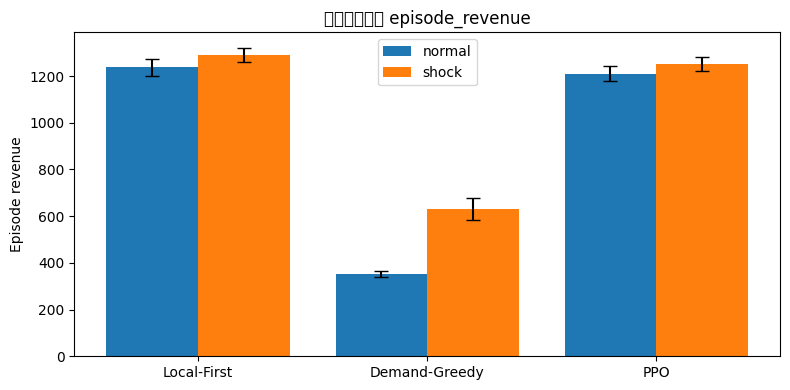

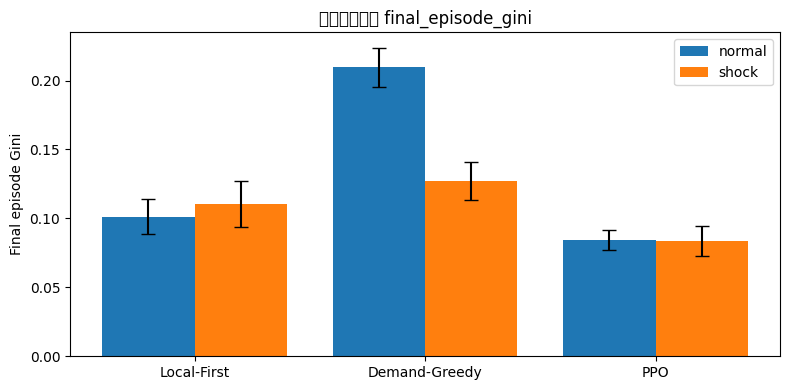

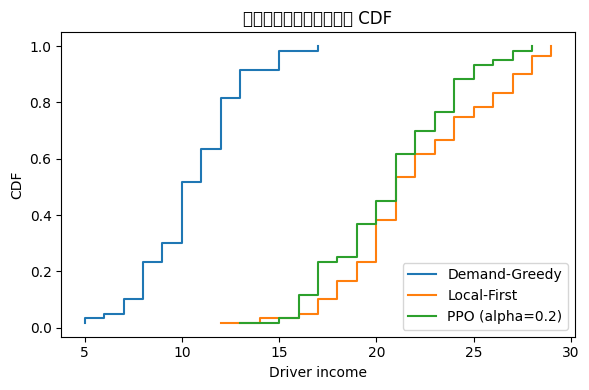

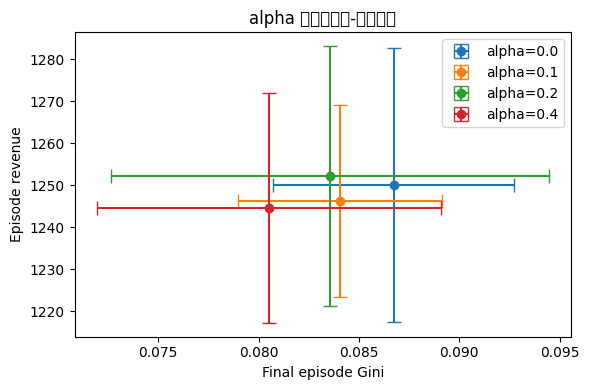

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

EXPORT_DIR = Path('figures')
EXPORT_DIR.mkdir(exist_ok=True)

# 读取统计汇总数据（用于添加误差棒）
stats_df = pd.read_csv('results/statistical_summary.csv')

# 图表1：不同场景下的 episode_revenue（带误差棒）
algorithms = ['Local-First', 'Demand-Greedy', 'PPO']
normal_rev_mean = []
normal_rev_std = []
shock_rev_mean = []
shock_rev_std = []

for algo in algorithms:
    if algo == 'PPO':
        normal_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'normal') & (stats_df['alpha'] == 0.2)]
        shock_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock') & (stats_df['alpha'] == 0.2)]
    else:
        normal_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'normal')]
        shock_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'shock')]
    
    normal_rev_mean.append(normal_row['revenue_mean'].values[0])
    normal_rev_std.append(normal_row['revenue_std'].values[0])
    shock_rev_mean.append(shock_row['revenue_mean'].values[0])
    shock_rev_std.append(shock_row['revenue_std'].values[0])

positions = np.arange(len(algorithms))
plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, normal_rev_mean, width=0.4, yerr=normal_rev_std, capsize=5, label='normal')
plt.bar(positions + 0.2, shock_rev_mean, width=0.4, yerr=shock_rev_std, capsize=5, label='shock')
plt.xticks(positions, algorithms)
plt.ylabel('Episode revenue')
plt.title('不同场景下的 episode_revenue')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'episode_revenue_by_scene.png', dpi=150)
plt.show()
plt.close()

# 图表2：不同场景下的 final_episode_gini（带误差棒）
normal_gini_mean = []
normal_gini_std = []
shock_gini_mean = []
shock_gini_std = []

for algo in algorithms:
    if algo == 'PPO':
        normal_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'normal') & (stats_df['alpha'] == 0.2)]
        shock_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock') & (stats_df['alpha'] == 0.2)]
    else:
        normal_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'normal')]
        shock_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'shock')]
    
    normal_gini_mean.append(normal_row['gini_mean'].values[0])
    normal_gini_std.append(normal_row['gini_std'].values[0])
    shock_gini_mean.append(shock_row['gini_mean'].values[0])
    shock_gini_std.append(shock_row['gini_std'].values[0])

plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, normal_gini_mean, width=0.4, yerr=normal_gini_std, capsize=5, label='normal')
plt.bar(positions + 0.2, shock_gini_mean, width=0.4, yerr=shock_gini_std, capsize=5, label='shock')
plt.xticks(positions, algorithms)
plt.ylabel('Final episode Gini')
plt.title('不同场景下的 final_episode_gini')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'final_gini_by_scene.png', dpi=150)
plt.show()
plt.close()

# 图表3：冲击场景下司机收入分布 CDF（保持单次实验数据）
plt.figure(figsize=(6, 4))
for label, values in shock_income_samples.items():
    sorted_values = sorted(values)
    y_values = [(idx + 1) / len(sorted_values) for idx in range(len(sorted_values))]
    plt.step(sorted_values, y_values, where='post', label=label)
plt.xlabel('Driver income')
plt.ylabel('CDF')
plt.title('冲击场景下司机收入分布 CDF')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'shock_income_cdf.png', dpi=150)
plt.show()
plt.close()

# 图表4：alpha 参数的效率-公平权衡（带误差棒）
ppo_shock_df = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock')].sort_values('alpha')
plt.figure(figsize=(6, 4))
for _, row in ppo_shock_df.iterrows():
    plt.errorbar(row['gini_mean'], row['revenue_mean'], 
                 xerr=row['gini_std'], yerr=row['revenue_std'],
                 fmt='o', capsize=5, label=f"alpha={row['alpha']}")
plt.xlabel('Final episode Gini')
plt.ylabel('Episode revenue')
plt.title('alpha 参数的效率-公平权衡')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'alpha_tradeoff.png', dpi=150)
plt.show()
plt.close()

## 结论

在这个模拟器里，PPO 在需求冲击场景下能让司机收入分布更均衡。主要证据来自 `PPO(alpha=0.2)` 和 `Local-First` 的 shock 场景对比。上面的表格和显著性检验需要一起看：更低的最终 `Gini` 说明收入分布更公平，而收入比较则用来判断这种公平改善是否伴随明显效率成本。

alpha 分析是一个有用的 robustness check，但还不是完整调参过程。`alpha=0.0` 展示了没有显式公平惩罚时 PPO 会学到什么；更高的 alpha 则展示更强公平压力如何改变 trade-off。如果几个 alpha 的结果很接近，就不能说某个 alpha 已经被证明最优，只能说 reward 权重还需要更系统地调。

最大的限制仍然是模拟器。公平性奖励需要用到完整的司机累计收入向量，但 PPO 策略实际只观察区域数量和上一时刻 Gini。现实中的道路结构、出行时间、司机拒单、动态价格和长期司机偏好都没有建模。后续如果继续做，应该换成订单级模拟器或真实平台数据，再检查这个公平性收益是否还能保留下来。

## 参考文献

1. Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). [Proximal policy optimization algorithms](https://arxiv.org/abs/1707.06347). arXiv:1707.06347. https://doi.org/10.48550/arXiv.1707.06347.

2. Xu, Z., Li, Z., Guan, Q., Zhang, D., Li, Q., Nan, J., Liu, C., Bian, W., & Ye, J. (2018). [Large-scale order dispatch in on-demand ride-hailing platforms: A learning and planning approach](https://www.kdd.org/kdd2018/accepted-papers/view/large-scale-order-dispatch-in-on-demand-ride-sharing-platforms-a-learning-a). Proceedings of the 24th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 905-913. https://doi.org/10.1145/3219819.3219824.

3. Tang, X., Qin, Z., Zhang, F., Wang, Z., Xu, Z., Ma, Y., Zhu, H., & Ye, J. (2019). [A deep value-network based approach for multi-driver order dispatching](https://kdd.org/kdd2019/accepted-papers/view/a-deep-value-network-based-approach-for-multi-driver-order-dispatching). Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 1780-1790. https://doi.org/10.1145/3292500.3330724.

4. Sun, J., Jin, H., Yang, Z., Su, L., & Wang, X. (2022). [Optimizing long-term efficiency and fairness in ride-hailing via joint order dispatching and driver repositioning](https://engineering.purdue.edu/~lusu/papers/KDD2022.pdf). Proceedings of the 28th ACM SIGKDD Conference on Knowledge Discovery and Data Mining, 3950-3960. https://doi.org/10.1145/3534678.3539060.

5. Liang, Y. (2024). [Fairness-aware dynamic ride-hailing matching based on reinforcement learning](https://www.mdpi.com/2079-9292/13/4/775). Electronics, 13(4), 775. https://doi.org/10.3390/electronics13040775.

6. Shi, C., Wang, X., Luo, S., Zhu, H., Ye, J., & Song, R. (2023). [Dynamic causal effects evaluation in A/B testing with a reinforcement learning framework](https://www.tandfonline.com/doi/abs/10.1080/01621459.2022.2027776). Journal of the American Statistical Association, 118(543), 2059-2071. https://doi.org/10.1080/01621459.2022.2027776.


## 运行与复现说明

所有 PPO 训练和批量实验都在 `Google Colab` 中完成。当前 notebook 默认读取已经保存好的结果文件，而不是打开时重新训练 PPO。这样报告可以快速查看，也避免评分时受硬件和训练时间影响。正文表格和图形依赖以下文件：

- `results/multi_seed_results.csv`
- `results/statistical_summary.csv`
- `results/significance_tests.csv`
- `results/baseline_shock_incomes.csv`
- `results/ppo_shock_incomes.csv`

如果需要从头复现更稳的 `10`-seed 结果，可以先安装 `requirements.txt` 中的依赖，然后在 Colab 中从当前文件夹执行：

1. `pip install -q -r requirements.txt`
2. `python scripts/evaluate_baselines.py`
3. `python scripts/run_multi_seed_experiments.py --seeds 0,42,123,456,789,2025,2026,2027,2028,2029 --total-timesteps 20000`
4. `python scripts/statistical_analysis.py --alpha 0.2`

多种子命令会生成 `120` 行 `results/multi_seed_results.csv`：`10` 个 seed × `2` 个场景 × `2` 个 baseline，加上 `10` 个 seed × `2` 个场景 × `4` 个 PPO alpha。训练和报告 notebook 分开，是因为 PPO 在 CPU 上可能比较慢。

## 小组贡献说明

本项目由 4 人小组共同完成。小组成员贡献相同，每人 `25%`。

小组成员与 candidate number：
- Haotian Wang（Candidate number: 67864）
- Jules Wang（Candidate number: 62036）
- Xiaotian Qi（Candidate number: 59789）
- Zhangrui Dong（Candidate number: 71902）

贡献百分比：Haotian Wang 25%，Jules Wang 25%，Xiaotian Qi 25%，Zhangrui Dong 25%。

主要工作内容包括环境建模、基线策略实现、PPO 训练、多种子实验、统计检验、图表生成和报告撰写。当前多种子实验使用 `10` 个 seed，共 `120` 条主实验记录。

说明：四位成员贡献相同，均为 25%。